In [1]:
import os
from langchain import hub
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, ToolMessage, BaseMessage, HumanMessage, AIMessage, FunctionMessage
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import END, StateGraph, MessagesState
from langgraph.graph.state import CompiledStateGraph

In [11]:
# Model parameters
DOCS_DIR = "../docs"
PERSIST_DIR = "../storage"
LLM_MODEL = "granite3.1-dense:8b"
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"

In [12]:
# Load LLM + embedding model
llm = ChatOllama(
    model=LLM_MODEL,
    temperature=0
)
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

In [19]:
## VECTOR STORE

# Check if the vector store already exists
if os.path.exists(PERSIST_DIR):
    print("Loading existing vector store...")
    vector_store = Chroma(
        persist_directory=PERSIST_DIR, embedding_function=embeddings
    )
else:
    print("Creating new vector store...")
    os.mkdir(PERSIST_DIR)
    # Process documents for RAG
    loader = DirectoryLoader(DOCS_DIR)
    docs = loader.load()
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000, chunk_overlap=200
    )
    all_splits = text_splitter.split_documents(docs)

    # Create a new vector store and add documents
    vector_store = Chroma.from_documents(
        documents=all_splits,
        embedding=embeddings,
        persist_directory=PERSIST_DIR,
    )
    print("Vector store created and documents indexed.")
print("Vector store loaded")
retriever = vector_store.as_retriever(k=1) # can be invoked later

Creating new vector store...


OperationalError: attempt to write a readonly database

In [5]:
graph_builder = StateGraph(MessagesState)

In [6]:
def retrieve(state: MessagesState):
    """Retrieve information related to a query."""
    retrieved_docs = retriever.invoke(state["messages"][-1].content)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}")
        for doc in retrieved_docs
    )
    return {"messages": [
        FunctionMessage(serialized, name="retrieve")
    ]}

In [7]:
def generate(state: MessagesState):
    """Generate answer."""
    retrieved_messages = []
    for message in reversed(state["messages"]):
        if message.type == "function":
            retrieved_messages.append(message)
        else:
            break
    retrieved_messages = retrieved_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in retrieved_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system", "ai")
    ]
    print(conversation_messages)
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

In [8]:
graph_builder.add_node(retrieve)
graph_builder.add_node(generate)

graph_builder.set_entry_point("retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

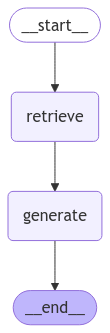

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
input_message = "Hello - what context have you been given?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello - what context have you been given?
=============================== Function Message ===============================
Name: retrieve


[HumanMessage(content='Hello - what context have you been given?', additional_kwargs={}, response_metadata={}, id='7e3cdedb-dd66-4a87-b459-42ab4acaceba')]
================================== Ai Message ==================================

I'm sorry for any confusion, but I haven't been provided with specific pieces of context in this conversation. I can only access and use context that has been explicitly shared within our current interaction. Please provide the context or ask your question directly, and I'll do my best to assist you.
